# Preliminary Design Specification of a commercial aircraft with electric propulsion system, LH2 and fuel cell
#### TU Wien 307.504 Aircraft Design I (WS2025) | Group 6

**Nov 24, 2025**

**Group 6 - Contributors**
- Lena Aveline
- Benoit Pereira
- Michael Riedl
- Matthias Frenzl


#### TU Wien 307.511 Aircraft Design II (SS2026) | Group 1

- Medeiros Dalla Costa Diego
- Starikov Nikita
- Michael Riedl
- Frenzl Matthias

## First mass estimation

In [369]:
# Imports
from math import *
from matplotlib import pyplot as plt
import numpy as np

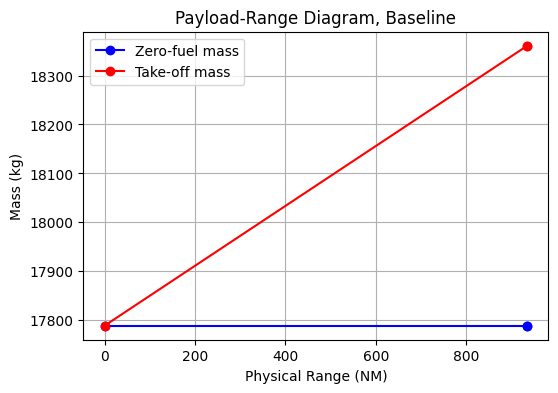

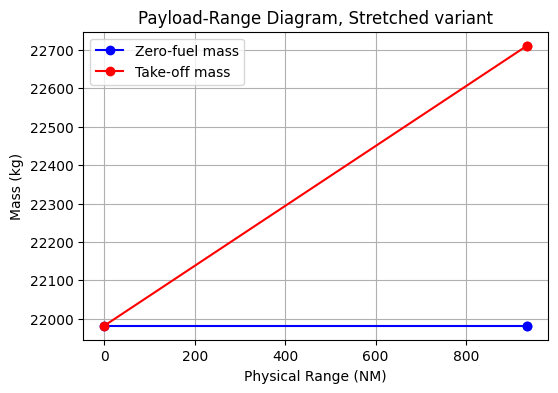

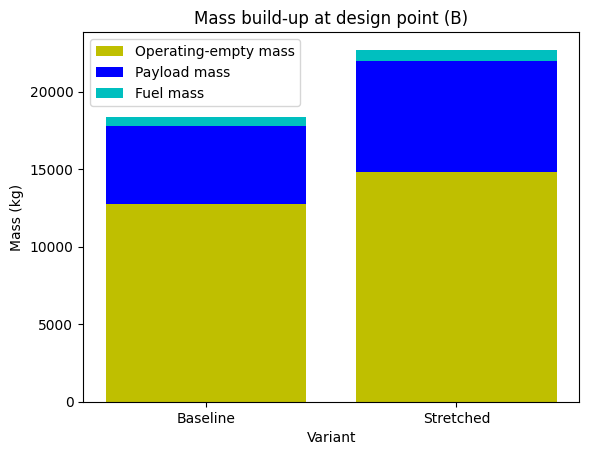

 === Ranges === 
Operational range = 700 NM
Physical range = 935 NM

 === Baseline (at design point) === 
Payload mass = 5060 kg
Fuel mass = 572 kg
Operating-empty mass = 12728 kg
Take-off mass = 18360 kg

 === Stretched variant (at design point) === 
Payload mass = 7150 kg
Fuel mass = 728 kg
Operating-empty mass = 14831 kg
Take-off mass = 22710 kg


In [370]:
# First Mass Estimation (Benoit Version)
##2025/11/21 - Initial mass estimation v2 - Benoit Pereira

from math import *
import matplotlib.pyplot as plt
import numpy as np

#Design specifications
NbPass_bas = 48                                         #Passenger number for baseline
NbPass_str = 70                                         #Passenger number for streched variant
mPass = 83                                              #Passenger mass (kg)
mLugg = 12                                              #Luggage mass per passenger (kg)
mFrght = 500                                            #Freight mass (kg)

rOP = 700                                               #Operational range (NM)
rDIV = 100                                              #Diversion range (NM)
CTGratio = 0.05                                         #Contingency ratio                      (proportion of operational range)
vHLD = 200                                              #Holding speed (knots)
tHLD = 0.5                                              #Holding time (hours)

################################################################################

#Estimations/Assumptions/Design choices
##Values from statistics
y = 0.28                                                #Payload factor (gamma)                 (proportion of payload relative to take-off mass)
k = 0.12                                                #Fuel factor (kappa)                    (proportion of fuel relative to take-off mass)

##Correction for better technologies
y = y*1.1                                               #Estimation of 10% increase of the payload factor by 2030
k = k*0.8                                               #Estimation of 20% decrease of the fuel factor by 2030

################################################################################

#First mass estimation
rCTG = CTGratio*rOP                                     #Contingency range
rHLD = vHLD*tHLD                                        #Holding range
rPH = rOP + rHLD + rDIV + rCTG                          #Physical range                         (includes reserves)

##Baseline
mP_bas = NbPass_bas*(mPass+mLugg) + mFrght              #Payload mass for baseline              (passenger + baggages + freight)
mTO_bas = mP_bas/y                                      #Take-off mass
mF_bas = k*mTO_bas                                      #Fuel mass
mOE_bas = (mTO_bas-mP_bas-mF_bas)                       #Operating-empty mass

k_bas = k*1.07*1.02*0.833*0.357                         #Correction for LHE propulsion
mOE_bas = 1.3 * mOE_bas                                 #Correction for LHE propulsion
mTO_bas = (mOE_bas+mP_bas)/(1-k_bas)                    #Correction for LHE propulsion
mF_bas = k_bas*mTO_bas                                  #Need to be computed again for new LHE fuel factor

##Stretched variant
k_str = 1.03*k_bas                                      #Corrected fuel factor for stretched version

mP_str = NbPass_str*(mPass+mLugg) + mFrght              #Payload mass for stretched variant
mOE_str = mOE_bas*(1+0.4*(mP_str-mP_bas)/mP_bas)        #Operating-empty mass for stretched variant
mTO_str = (mOE_str+mP_str)/(1-k_str)                    #Take_off mass for stretched variant
mF_str = k_str*mTO_str                                  #Fuel mass for stretched variant

################################################################################

#Payload-Range Diagrams
##Baseline
r_vals = [0, rPH, rPH]
mZF_vals = [mP_bas+mOE_bas, mP_bas+mOE_bas, mTO_bas-mF_bas]
mTO_vals = [mP_bas+mOE_bas, mTO_bas, mTO_bas]

plt.figure(figsize=(6,4))
plt.plot(r_vals, mZF_vals, 'o-', color = 'blue', label = 'Zero-fuel mass')
plt.plot(r_vals, mTO_vals, 'o-', color = 'red', label = 'Take-off mass')
plt.xlabel("Physical Range (NM)")
plt.ylabel("Mass (kg)")
plt.title(f"Payload-Range Diagram, Baseline")
plt.legend()
plt.grid()
plt.show()

##Stretched variant
r_vals = [0, rPH, rPH]
mZF_str_vals = [mP_str+mOE_str ,mP_str+mOE_str, mTO_str-mF_str]
mTO_str_vals = [mP_str+mOE_str, mTO_str, mTO_str]

plt.figure(figsize=(6,4))
plt.plot(r_vals, mZF_str_vals, 'o-', color = 'blue', label = 'Zero-fuel mass')
plt.plot(r_vals, mTO_str_vals, 'o-', color = 'red', label = 'Take-off mass')
plt.xlabel("Physical Range (NM)")
plt.ylabel("Mass (kg)")
plt.title(f"Payload-Range Diagram, Stretched variant")
plt.legend()
plt.grid()
plt.show()

################################################################################

#Masses build-up
categories = ['Baseline', 'Stretched']
mOE = np.array([mOE_bas, mOE_str])
mP = np.array([mP_bas, mP_str])
mF = np.array([mF_bas, mF_str])

plt.bar(categories, mOE, color='y', label='Operating-empty mass')
plt.bar(categories, mP, bottom=mOE, color='b', label='Payload mass')
plt.bar(categories, mF, bottom=mOE + mP, color='c', label='Fuel mass')
plt.xlabel("Variant")
plt.ylabel("Mass (kg)")
plt.title("Mass build-up at design point (B)")
plt.legend()
plt.show()

################################################################################

#Results
print(" === Ranges === ")
print("Operational range =", int(rOP), "NM")
print("Physical range =", int(rPH), "NM")
print()
print(" === Baseline (at design point) === ")
print("Payload mass =", int(mP_bas), "kg")
print("Fuel mass =", int(mF_bas), "kg")
print("Operating-empty mass =", int(mOE_bas), "kg")
print("Take-off mass =", int(mTO_bas), "kg")
print()
print(" === Stretched variant (at design point) === ")
print("Payload mass =", int(mP_str), "kg")
print("Fuel mass =", int(mF_str), "kg",)
print("Operating-empty mass =", int(mOE_str), "kg")
print("Take-off mass =", int(mTO_str), "kg")

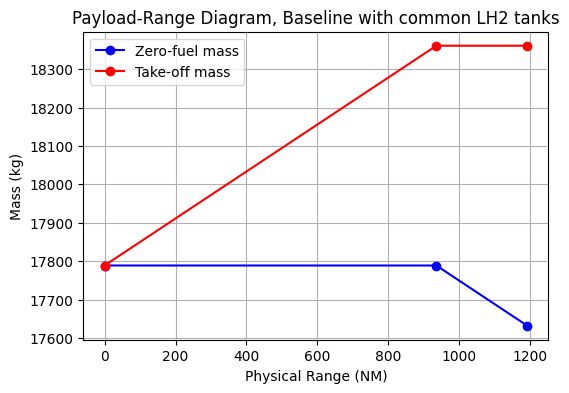

 === Baseline (at point C) === 
Operational range = 944 NM
Physical range = 1191 NM

Payload mass = 4903 kg
Fuel mass = 728 kg
Operating-empty mass = 12728 kg
Take-off mass = 18360 kg


In [371]:
# Discussion about LH2 tanks commonality
##2026/01/11 - impacts of LH2 tanks commonality - Benoit Pereira

mF_max = mF_str                                         #fuel mass is now the same as for the stretched variant

################################################################################

#Impacts
rPH_max = mF_max/mF_bas * rPH                           #Physical range is extended (assuming proportionality between fuel mass and physical range)
rOP_max = (rPH_max - rHLD - rDIV)/(1+CTGratio)          #Operational range is extended (deducing reserves from the extended physical range)

################################################################################

#Payload-Range Diagram
##Baseline with common LH2 tanks
r_vals = [0, rPH, rPH_max]
mZF_vals = [mP_bas+mOE_bas ,mP_bas+mOE_bas, mTO_bas-mF_max]
mTO_vals = [mP_bas+mOE_bas, mTO_bas, mTO_bas]

plt.figure(figsize=(6,4))
plt.plot(r_vals, mZF_vals, 'o-', color = 'blue', label = 'Zero-fuel mass')
plt.plot(r_vals, mTO_vals, 'o-', color = 'red', label = 'Take-off mass')
plt.xlabel("Physical Range (NM)")
plt.ylabel("Mass (kg)")
plt.title(f"Payload-Range Diagram, Baseline with common LH2 tanks")
plt.legend()
plt.grid()
plt.show()

################################################################################

#Results
print(" === Baseline (at point C) === ")
print("Operational range =", int(rOP_max), "NM")
print("Physical range =", int(rPH_max), "NM")
print()
print("Payload mass =", int(mTO_bas-mOE_bas-mF_max), "kg")
print("Fuel mass =", int(mF_max), "kg")
print("Operating-empty mass =", int(mOE_bas), "kg")
print("Take-off mass =", int(mTO_bas), "kg")

## Initial propulsion system sizing

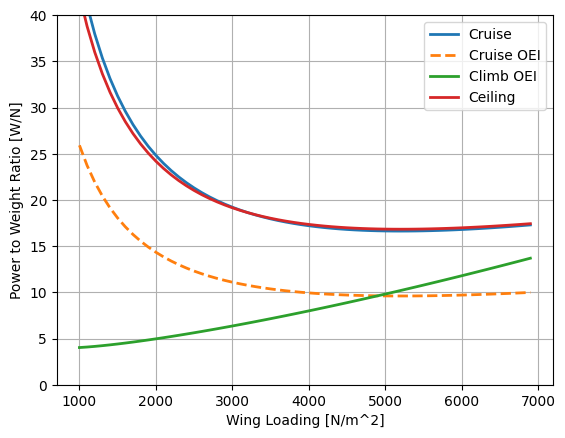

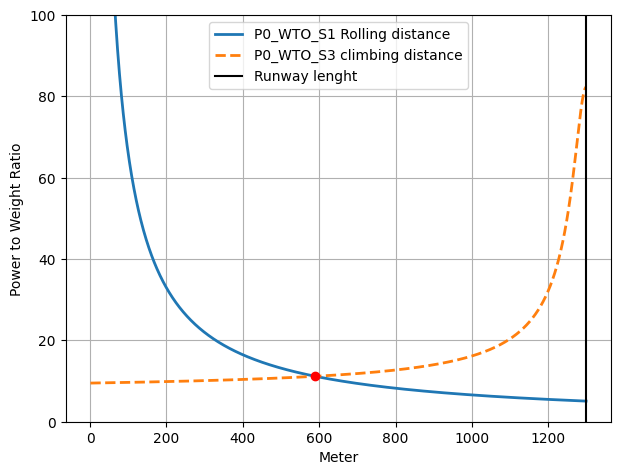

Optimal Wing Loading (W/S) : 5200 [N/m^2]
Minimal Power to Weight ratio(P0/W_TO) : 16.8306 [W/N]


In [372]:
# Baseline propulsion sizing
##Propulsion Sizing -Base Variante - Michael Riedl

#Assumptions
S=50                            #Wing Area [m^2]
Epsilon=1/18                    #Based on slide 22
FL=290
c=304.484                       #Speed of sound at this flight level according to Isa Calculator
Ma=0.515                        #Based on Slide 15 with FL290 and 3000N/m^2 wing loading
g=9.81                          #gravitation
n_E=4                           #Number of engines
rho_OEI=0.475448                #At 29 000ft
cL_maxTO=2.3                    #Based on slide 40
rho_0=1.22500                   #air density at see level

#given Values
hscr=35                         #obstacle hight of 35ft, based on slide 43
E_ToOEI =1/10
dh_ds=0.03                     # Based on slide 47
E_2OEI=0.8*E_ToOEI
kc=0.99                         #correction for weight loss
TR_THR=0.8                      #Power throttle
eta_Trans=0.99                  #Transmission efficency
eta_Prop=0.9                    #Propeller efficency

#Calculations
W_S=mTO_bas*g/S                 #Wing Loading base variante [N/m^2]
v=c*Ma*1.944                    #Speed in knots (m/s->knots) [knots]
v_ms=v/1.944                    #Speed in m/s
#P0_WTO=(kc*Epsilon*v)/(eta_Prop*eta_Trans*TR_THR)       #Power to Weight Ratio [W/N]
P0=P0_WTO*(mOE_bas*g)
#One engine inoperative
q_OEI=rho_OEI*(v/1.944)**2/2
Epsilon_OEI=1.1*Epsilon
v_OEI=(2*q_OEI/rho_OEI)**0.5
TR_THR_0EI=0.95
P0_OEI=(n_E-1)/n_E*P0
P0_WTO_OEI=(Epsilon_OEI*kc*v_OEI*n_E)/(TR_THR_0EI*eta_Trans*eta_Prop*(n_E-1))

#Speeds
v_SR=sqrt((2*1)/(cL_maxTO*rho_0)*(mOE_bas*g)/S)
v_LOF=1.08*v_SR
v2_min=1.08*v_SR
s1=np.arange(1,1300)
s3=1300-s1
hscr_over_s3 = hscr / s3
T_WTO_s1=1.15/(g*rho_0*cL_maxTO*s1*(1-1/(2*n_E)))*(mOE_bas*g)/(S*(1-0.03-0.13))
P0_WTO_S1=(T_WTO_s1*0.71*v_LOF)/(1*0.99*0.7)
T_WTO_s3 = (np.sin(np.arctan(hscr_over_s3)) + E_ToOEI) / (1 - 1/n_E)
P0_WTO_S3=(T_WTO_s3*1/2*(v_LOF+v2_min))/(1*eta_Prop*eta_Prop)
P0_WTO_2OEI=(dh_ds+E_2OEI)*v2_min/(1*eta_Prop*eta_Trans)*n_E/(n_E-1)
P0_WTO_Ceiling=((300/(v*196.85))+Epsilon)*v/(0.9*0.99*0.9)                         #300ft/min climb speed und horizontal speed Ma=0.515 but also in feet/min

#P/W as function of WS
W_S_v=np.arange(1000,7000,100)
q=0.5*rho_0*v_ms**2
AR=8            #Aspect Ratio
e0=0.7          #Oswald factor
C_L=(mTO_bas*g)/(q*S)
k=1/(pi*AR*e0)
CD0=(Epsilon*C_L)-2/(pi*AR*e0)*C_L**2
Epsilon_2OEI=((q_OEI*CD0)/W_S_v)+(k*W_S_v)/q_OEI
Epsilon_WS=((q*CD0)/W_S_v)+(k*W_S_v)/q
v_SR_WS=np.sqrt((2*1)/(cL_maxTO*rho_0)*W_S_v)
v2_min_WS=1.13*v_SR_WS
P0_WTO_WS=((q*CD0/W_S_v)+k*W_S_v/q)*kc*v/(eta_Prop*eta_Trans*TR_THR)
P0_WTO_OEI_WS=((q*CD0/W_S_v)+k*W_S_v/q)*kc*v_OEI/(eta_Prop*eta_Trans*TR_THR_0EI)*n_E/(n_E-1)
P0_WTO_2OEI_WS=(dh_ds+Epsilon_2OEI)*(v2_min_WS*n_E)/((1*0.8*eta_Trans)*(n_E-1))
P0_WTO_Ceiling_WS=((300/(v*196.85))+Epsilon_WS)*v/(0.9*0.99*0.9)
plt.ylim(0,40)
plt.xlabel("Wing Loading [N/m^2]")
plt.ylabel("Power to Weight Ratio [W/N]")
plt.grid(True)
plt.plot(W_S_v,P0_WTO_WS,label="Cruise",linewidth=2)
plt.plot(W_S_v,P0_WTO_OEI_WS,'--',label="Cruise OEI",linewidth=2)
plt.plot(W_S_v,P0_WTO_2OEI_WS,label="Climb OEI",linewidth=2)
plt.plot(W_S_v,P0_WTO_Ceiling_WS,label="Ceiling",linewidth=2)
plt.legend()
plt.show()
plt.xlabel("Meter")
plt.ylabel("Power to Weight Ratio")
plt.grid(True)

plt.plot(s1, P0_WTO_S1, label="P0_WTO_S1 Rolling distance", linewidth=2)
plt.plot(s1, P0_WTO_S3, '--', label="P0_WTO_S3 climbing distance", linewidth=2)
plt.axvline(1300,color='black',label='Runway lenght')
plt.legend()
plt.tight_layout()
plt.ylim(0, 100)
idx = np.argmin(np.abs(P0_WTO_S1 - P0_WTO_S3))   # Find the crossing point of the two curves
x_intersect = s1[idx]
y_intersect = P0_WTO_S1[idx]
plt.plot(x_intersect, y_intersect, 'ro')
plt.show()


# ---FIND THE OPTIMAL DESIGN POINT (OP)---

max_P0_WTO = np.maximum.reduce([P0_WTO_WS, P0_WTO_OEI_WS, P0_WTO_2OEI_WS, P0_WTO_Ceiling_WS])
min_idx = np.argmin(max_P0_WTO)
W_S_opt = W_S_v[min_idx]
P0_WTO_min = max_P0_WTO[min_idx]

print(f"Optimal Wing Loading (W/S) : {W_S_opt} [N/m^2]")
print(f"Minimal Power to Weight ratio(P0/W_TO) : {P0_WTO_min:.4f} [W/N]")




Required Power to Weight Ratio  for stretched variant to take of in given Runway lenght: 11.69 [W/N]


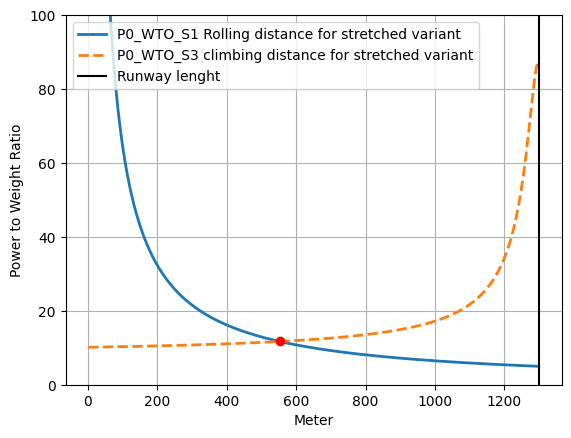

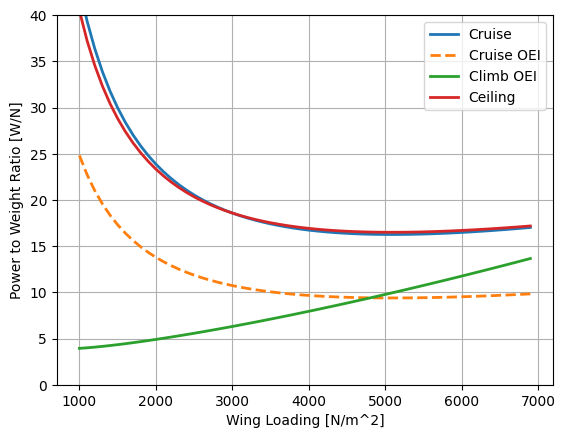

In [373]:
# Stretched Variant

#Calculations
W_S_Str=mTO_str*g/S                                     #Wing Loading streched variant [N/m²]
P0_WTO=(kc*Epsilon*v)/(eta_Prop*eta_Trans*TR_THR)       #Power to Weight Ratio [W/N]
P0_str=P0_WTO*(mOE_str*g)
#One engine inoperative
P0_OEI=(n_E-1)/n_E*P0_str
P0_WTO_OEI_str=(Epsilon_OEI*kc*v_OEI)/(TR_THR_0EI*eta_Trans*eta_Prop)*n_E/(n_E-1)

#Speeds
v_SR_str=sqrt((2*1)/(cL_maxTO*rho_0)*(mOE_str*g)/S)
v_LOF_str=1.08*v_SR_str
v2_min_str=1.13*v_SR_str
T_WTO_s1_str=1.15/(g*rho_0*cL_maxTO*s1*(1-1/(2*n_E)))*(mOE_str*g)/(S*1-0.03-0.13)
P0_WTO_S1_str=(T_WTO_s1_str*0.71*v_LOF)/(1*0.99*0.7)
T_WTO_s3_str = (np.sin(np.arctan(hscr_over_s3)) + E_ToOEI) / (1 - 1/n_E)
P0_WTO_S3_str=(T_WTO_s3_str*1/2*(v_LOF+v2_min_str))/(1*eta_Prop*eta_Prop)
P0_WTO_2OEI_str=(dh_ds+E_2OEI)*v2_min_str/(1*0.8*eta_Trans)*n_E/(n_E-1)
P0_WTO_Ceiling_str=(300/(v*196.85)+Epsilon)*v/(0.9*0.99*0.9)                         #300ft/min climb speed und horizontal speed Ma=0.6 but also in feet/min

#Result
plt.xlabel("Meter")
plt.ylabel("Power to Weight Ratio")
plt.grid(True)

plt.plot(s1, P0_WTO_S1_str, label="P0_WTO_S1 Rolling distance for stretched variant", linewidth=2)
plt.plot(s1, P0_WTO_S3_str, '--', label="P0_WTO_S3 climbing distance for stretched variant", linewidth=2)
idx = np.argmin(np.abs(P0_WTO_S1_str - P0_WTO_S3_str))   # Find the crossing point of the two curves
plt.axvline(1300,color='black',label='Runway lenght')
plt.legend()
plt.ylim(0, 100)
x_intersect = s1[idx]
y_intersect = P0_WTO_S1_str[idx]
print("Required Power to Weight Ratio  for stretched variant to take of in given Runway lenght:", round(y_intersect,2),"[W/N]")
plt.plot(x_intersect, y_intersect, 'ro')
plt.show()

#P/W stretch Variant as function of WS
C_L_str=(mTO_str*g)/(q*S)
CD0_str=(Epsilon*C_L_str)-2/(pi*AR*e0)*C_L_str**2
Epsilon_2OEI_str=((q_OEI*CD0_str)/W_S_v)+(k*W_S_v)/q_OEI
Epsilon_WS_str=((q*CD0_str)/W_S_v)+(k*W_S_v)/q
P0_WTO_WS_str=((q*CD0_str/W_S_v)+k*W_S_v/q)*kc*v/(eta_Prop*eta_Trans*TR_THR)
P0_WTO_OEI_WS_str=((q*CD0_str/W_S_v)+k*W_S_v/q)*kc*v_OEI/(eta_Prop*eta_Trans*TR_THR_0EI)*n_E/(n_E-1)
P0_WTO_2OEI_WS_str=(dh_ds+Epsilon_2OEI_str)*(v2_min_WS*n_E)/((1*0.8*eta_Trans)*(n_E-1))
P0_WTO_Ceiling_WS_str=((300/(v*196.85))+Epsilon_WS_str)*v/(0.9*0.99*0.9)
plt.figure()
plt.ylim(0,40)
plt.xlabel("Wing Loading [N/m^2]")
plt.ylabel("Power to Weight Ratio [W/N]")
plt.grid(True)
plt.plot(W_S_v,P0_WTO_WS_str,label="Cruise",linewidth=2)
plt.plot(W_S_v,P0_WTO_OEI_WS_str,'--',label="Cruise OEI",linewidth=2)
plt.plot(W_S_v,P0_WTO_2OEI_WS_str,label="Climb OEI",linewidth=2)
plt.plot(W_S_v,P0_WTO_Ceiling_WS_str,label="Ceiling",linewidth=2)
plt.legend()
plt.show()



In [374]:
#Landing Requirements and Propeller Dimensioning Baseline Variante
cL_maxL=2.8                                           #Based on slide 57
WL_S=W_S*(1-k)                                        #Wing loading at landing
vS=np.sqrt((2*WL_S)/(rho_0*cL_maxL))
vL=1.13*vS                                            #Landing Speed
qL=0.5*rho_0*vL**2
Epsilon_L=(qL*CD0)/W_S+(k*W_S)/qL
h50=50
sL=(WL_S/(rho_0*cL_maxL))*((1.23**2-1.13**2)/(g*Epsilon_L)-1.13**2/-3)+h50/Epsilon_L #Landing distance
v50=1.23*vS*1.944                                     #Approch speed in knots

print("Landing Requirements Baseline Variante")
print("Total Landing distance= ",round(sL,2),"m")
print("Approch speed= ",round(v50,2),"knots")
K_Prop=0.49                                           #Based on slide 62
Pbr_E_base=eta_Trans*17*(mTO_bas*g)/(n_E*1000)        #Power per engine baseline variante in kW with an P0_WTO of 17W/N
d_prop_base=K_Prop*Pbr_E_base**(1/4)                  #Propeller Diameter Baseline Variante)
print("Propeller Diameter Baseline Variante= ",round(d_prop_base,2),"m")


#Landing Requirements and Propeller Dimensioning stretch Variante

WL_S_str=W_S_Str*(1-k)                                #Wing loading at landing
vS_str=np.sqrt((2*WL_S_str)/(rho_0*cL_maxL))
vL_str=1.13*vS_str                                    #Landing Speed
Epsilon_L_str=(qL*CD0)/W_S_Str+(k*W_S)/qL
sL_str=(WL_S_str/(rho_0*cL_maxL))*((1.23**2-1.13**2)/(g*Epsilon_L_str)-1.13**2/-3)+h50/Epsilon_L_str #Landing distance
v50_str=1.23*vS_str*1.944                             #Approch speed in knots

print("Landing Requirements stretch Variante")
print("Total Landing distance= ",round(sL_str,2),"m")
print("Approch speed= ",round(v50_str,2),"knots")

Pbr_E_stretch=eta_Trans*17*(mTO_str*g)/(n_E*1000)     #Power per engine stretch variante in kW with an P0_WTO of 17W/N
d_prop_stretch=K_Prop*Pbr_E_stretch**(1/4)            #Propeller Diameter stretch Variante)
print("Propeller Diameter stretch Variante= ",round(d_prop_stretch,2),"m")

Landing Requirements Baseline Variante
Total Landing distance=  968.22 m
Approch speed=  106.43 knots
Propeller Diameter Baseline Variante=  2.57 m
Landing Requirements stretch Variante
Total Landing distance=  1112.34 m
Approch speed=  118.37 knots
Propeller Diameter stretch Variante=  2.71 m


###Commonalities impacts

In [375]:
# Discussion about wings, engines and propellers commonality
##2026/01/10 - Selected values and commonalities impacts - Benoit Pereira

#Choices
W_S_str_com = 4500                                    #Chosen wing loading for stretched variant (N/m²)
P0_WTO_str_com = 17                                   #Chosen power to weight for stretched variant(W/N)

################################################################################

#Retroactive impacts on baseline parameters
W_S_bas_com = mTO_bas/mTO_str * W_S_str_com           #Effective wingloading  for baseline with common wings (N/m²)
P0_WTO_bas_com = mTO_str/mTO_bas * P0_WTO_str_com     #Effective power-to-weight ratio for baseline with common engines (W/N)

#Other commonalities impacts
D_prop = d_prop_stretch                               #Propeller commonality impact on propeller diameter (m)                 -> to meet stretched variant requirements
Pmec_Mot = P0_WTO_str_com*eta_Trans*mTO_str*g/1000    #Engine commonality impact on combined power output of the motors (kW)  -> to meet stretched variant requirements

################################################################################

#Results
print("This gives the baseline an effective wingloading of", int(W_S_bas_com), "N/m²")
print("This gives the baseline an effective power-to-weight ratio of", int(P0_WTO_bas_com), "W/N")
print()
print("The common propeller diameter is", round(D_prop, 2), "m")
print("The common engines have a combined power output of", int(Pmec_Mot), "kW")



This gives the baseline an effective wingloading of 3638 N/m²
This gives the baseline an effective power-to-weight ratio of 21 W/N

The common propeller diameter is 2.71 m
The common engines have a combined power output of 3749 kW


## Hydrogen systems

Minimum FC system mass :
  FCload = 0.582
  mFC_tot = 2264.12 kg
  etaFC_stack = 0.515

Minimum FC system volume :
  FCload = 0.582
  VFC_tot = 3393.08 L
  etaFC_stack = 0.515


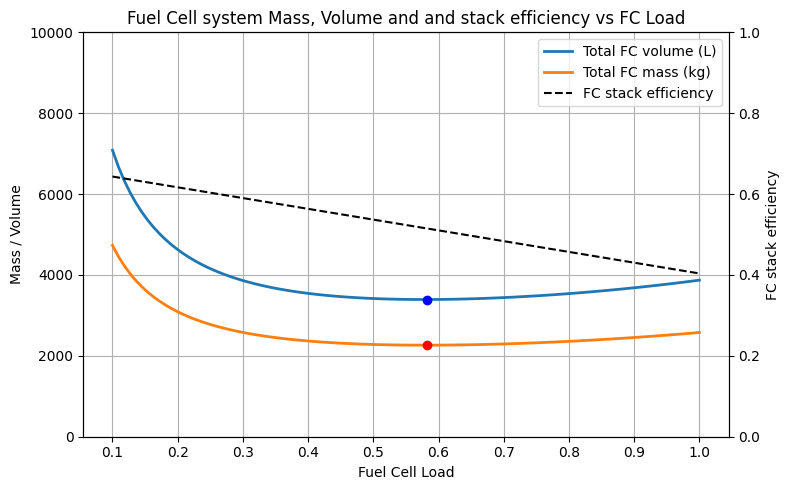

In [376]:
# Hydrogen systems
##2026/01/16 - Fuel Cells load optimizer - Benoit Pereira

from math import *
import matplotlib.pyplot as plt
import numpy as np

#Constants
etaInv = 0.99                 #Efficiency of the inverters
etaMot = 0.99                 #Efficiency of the electric motors
etaTrans = 0.98               #Efficiency of the transmission
etaFC_anc = 0.93              #Efficiency of the fuel cells considering the ancillaries

etaFC_cool = 0.8              #Fraction of the heat produced by the fuel cells that must be dissipated by the cooling system

Pmr_FC_stack_100 = 9          #power-mass ratio for fuel cells stack at 100% load (kW/kg)
Pmr_FC_stack_33 = 3           #power-mass ratio for fuel cells stack at 33% load (kW/kg)
PVr_FC_stack_100 = 6          #power-volume ratio for fuel cells stack at 100% load (kW/L)
PVr_FC_stack_33 = 2           #power-volume ratio for fuel cells stack at 33% load (kW/L)

mPr_FC_anc = 0.17             #mass-power ratio for fuel cells ancillaries (at any load) (kg/kW)
VPr_FC_anc = 0.25             #volume-power ratio for fuel cells ancillaries (at any load) (L/kW)

mPr_FC_cool = 0.33            #mass-power ratio for fuel cells cooling (at any load) (kg/kW)
VPr_FC_cool = 0.50            #volume-power ratio for fuel cells cooling (at any load) (L/kW)

################################################################################

#Assumptions
TR_crs = 0.8                  #throttle ratio during cruise
TR_clmb = 0.9                 #throttle ratio  during climb
TR_to = 1                     #throttle ratio at take-off

################################################################################

#Calculations
##Powers
Pel_Mot = Pmec_Mot / etaMot
Pel_Inv = Pel_Mot / etaInv

Pel_nonProp = 0.0625 * Pel_Inv
Pel_FC_syst_crs = Pel_Inv * (TR_crs + 0.0625)
Pel_FC_syst_clmb = Pel_Inv * (TR_clmb + 0.0625)

##Fuel cells masses and volume vs Fuel Cells load
FCload_vec = np.linspace(0.1, 1.0, 100)

mFC_tot_vec = []
VFC_tot_vec = []
etaFC_stack_vec = []

for FCload in FCload_vec:

    ###Stack efficiency
    etaFC_stack = -0.213 * FCload * TR_to / TR_crs + 0.67
    etaFC_stack_vec.append(etaFC_stack)

    ###Cooling heat
    Qcool = etaFC_cool * Pel_Inv * (TR_to + 0.0625) * (1 / etaFC_stack - 1)

    ###Interpolated stack ratios
    mPr_FC_stack_load = 1 / (((Pmr_FC_stack_100 - Pmr_FC_stack_33) / (1 - 0.33)) * (FCload - 0.33) + Pmr_FC_stack_33)
    VPr_FC_stack_load = 1 / (((PVr_FC_stack_100 - PVr_FC_stack_33) / (1 - 0.33)) * (FCload - 0.33) + PVr_FC_stack_33)

    ###Volumes
    VFC_stack = Pel_FC_syst_crs * VPr_FC_stack_load
    VFC_anc = Pel_FC_syst_clmb * VPr_FC_anc
    VFC_cool = Qcool * VPr_FC_cool

    ###Masses
    mFC_stack = Pel_FC_syst_crs * mPr_FC_stack_load
    mFC_anc = Pel_FC_syst_clmb * mPr_FC_anc
    mFC_cool = Qcool * mPr_FC_cool

    ###Totals
    VFC_tot = VFC_stack + VFC_anc + VFC_cool
    mFC_tot = mFC_stack + mFC_anc + mFC_cool

    VFC_tot_vec.append(VFC_tot)
    mFC_tot_vec.append(mFC_tot)

##Minima
###Convert to numpy arrays
mFC_tot_vec = np.array(mFC_tot_vec)
VFC_tot_vec = np.array(VFC_tot_vec)
etaFC_stack_vec = np.array(etaFC_stack_vec)

###Indices of minima
idx_m_min = np.argmin(mFC_tot_vec)
idx_V_min = np.argmin(VFC_tot_vec)

###Optimal FCload values
FCload_m_min = FCload_vec[idx_m_min]
FCload_V_min = FCload_vec[idx_V_min]

###Minimum values
mFC_min = mFC_tot_vec[idx_m_min]
VFC_min = VFC_tot_vec[idx_V_min]

###Corresponding efficiencies
eta_m_min = etaFC_stack_vec[idx_m_min]
eta_V_min = etaFC_stack_vec[idx_V_min]

################################################################################

#Results
print(f"Minimum FC system mass :")
print(f"  FCload = {FCload_m_min:.3f}")
print(f"  mFC_tot = {mFC_min:.2f} kg")
print(f"  etaFC_stack = {eta_m_min:.3f}\n")

print(f"Minimum FC system volume :")
print(f"  FCload = {FCload_V_min:.3f}")
print(f"  VFC_tot = {VFC_min:.2f} L")
print(f"  etaFC_stack = {eta_V_min:.3f}")

################################################################################

#Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

##First axis for total FC mass and volume
ax1.plot(FCload_vec, VFC_tot_vec, label='Total FC volume (L)', linewidth=2)
ax1.plot(FCload_vec, mFC_tot_vec, label='Total FC mass (kg)', linewidth=2)
ax1.scatter(FCload_m_min, mFC_min, color='red', zorder=5)
ax1.scatter(FCload_V_min, VFC_min, color='blue', zorder=5)
ax1.set_xlabel('Fuel Cell Load')
ax1.set_xticks(np.arange(0.1, 1.01, 0.1))
ax1.set_ylabel('Mass / Volume')
ax1.set_ylim(0, 10000)
ax1.grid(True)

##Secondary axis for efficiency
ax2 = ax1.twinx()
ax2.plot(FCload_vec, etaFC_stack_vec, 'k--', label='FC stack efficiency')
ax2.set_ylabel('FC stack efficiency')
ax2.set_ylim(0, 1)

##Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title('Fuel Cell system Mass, Volume and and stack efficiency vs FC Load')
plt.tight_layout()
plt.show()



In [377]:
# Hydrogen systems
##2025/12/12 - Hydrogen systems mass and volume estimation - Benoit Pereira

from math import *
import matplotlib.pyplot as plt
import numpy as np

#Constants and design specifications
d_LH2 = 0.0708                #Density of LH2 (kg/L)
gravEff_LH2 = 0.5             #Proposed gravimetric efficiency of LH2 fuel tanks

mPr_Batt = 1/10               #mass-power ratio for batteries (kg/kW)
VPr_Batt = 1/7.5              #volume-power ratio for batteries (L/kW)

mPr_Inv = 1/25                #mass-power ratio for inverters (kg/kW)
VPr_Inv = 1/25                #volume-power ratio for inverters (L/kW)

mPr_Mot = 1/12.5              #mass-power ratio for e-motors (kg/kW)
VPr_Mot = 1/25                #volume-power ratio for e-motors (L/kW)

################################################################################

#Estimations/Assumptions/Design choices
BatPowerRatio = 0.1           #Batteries (booster pack) should provide an increase of power equal to 10% of the motors max power (for exceptional scenarios)
BatVolt = 3.7                 #Batteries (booster pack) voltage (V)
BatCrating = 40               #Batteries (booster pack) C-rating (C)

Chosen_FCload = 0.45          #Fuel cells are oversized to be used at 45% charge during cruise

################################################################################

#Calculations
##LH2 tanks
VTanks = 1.072*mF_max/d_LH2                                   #tanks volume (1.072x larger than pure fuel volume) (L)
mTanks = mF_max*(1/gravEff_LH2-1)                             #tanks mass (without fuel) (kg)
mTanks_Inst = mTanks*0.05                                     #Tanks installation systems mass (kg)
mFuelDist = mTanks*0.15                                       #Fuel distribution systems mass (kg)

##Powers
Pel_Mot = Pmec_Mot/etaMot                                     #Power input in the motors (= output of the inverters) (kW)
Pel_Inv = Pel_Mot/etaInv                                      #Power input in the inverters (= output of the fuel cells for propulsive purposes) (kW)

PelBat = BatPowerRatio*Pel_Mot                                #Power output of the batteries (kW)

Pel_nonProp = 0.0625*Pel_Inv                                  #Power for non propulsive purposes (kW)
Pel_FC_syst_crs = Pel_Inv*(TR_crs+0.0625)                     #Power output from the fuel cells entire system during cruise (kW)
Pel_FC_syst_clmb = Pel_Inv*(TR_clmb+0.0625)                   #Power output from the fuel cells entire system during climb (kW)
Pel_stack = Pel_FC_syst_crs/etaFC_anc                         #Power output of the fuel cells stack (during cruise) (kW)

etaFC_stack = -0.213*Chosen_FCload* TR_to/TR_crs +0.67         #Stack efficiency (depends of the load)
Qcool = etaFC_cool*Pel_Inv*(TR_to+0.0625)*(1/etaFC_stack-1)   #Heat flow handled by fuel cells cooling

##Fuels cells
mPr_FC_stack_load = 1 / (((Pmr_FC_stack_100 - Pmr_FC_stack_33)/(1-0.33)) * (Chosen_FCload-0.33) + Pmr_FC_stack_33)         #linearly interpolated mass-power ratio for (oversized) fuel cells stack (kg/kW)
VPr_FC_stack_load = 1 / (((PVr_FC_stack_100 - PVr_FC_stack_33)/(1-0.33)) * (Chosen_FCload-0.33) + PVr_FC_stack_33)         #linearly interpolated volume-power ratio for (oversized) fuel cells stack (L/kW)

VFC_stack = Pel_FC_syst_crs*VPr_FC_stack_load                 #Fuel cells stack volume (L)
mFC_stack = Pel_FC_syst_crs*mPr_FC_stack_load                 #Fuel cells stack mass (kg)
VFC_anc = Pel_FC_syst_clmb*VPr_FC_anc                         #Fuel cells ancillaries volume (L)
mFC_anc = Pel_FC_syst_clmb*mPr_FC_anc                         #Fuel cells ancillaries mass (kg)
VFC_cool = Qcool*VPr_FC_cool                                  #Fuel cells cooling volume (L)
mFC_cool = Qcool*mPr_FC_cool                                  #Fuel cells cooling mass (kg)

VFC_tot = VFC_stack + VFC_anc + VFC_cool                      #Total fuel cells system volume (L)
mFC_tot = mFC_stack + mFC_anc + mFC_cool                      #Total fuel cells system mass (kg)

##Batteries
VBatt = PelBat*mPr_Batt                                       #Batteries volume (L)
mBatt = PelBat*mPr_Batt                                       #Batteries mass (kg)
BatCap = PelBat/BatVolt*BatCrating                            #Batteries capacity (kAh)

##Inverters
VInv = Pel_Inv*VPr_Inv                                        #Inverters volume (L)
mInv = Pel_Inv*mPr_Inv                                        #Inverters mass (kg)

##E_motors
VMot = Pel_Mot*VPr_Mot                                        #total motors volume (include gearbox) (L)
mMot = Pel_Mot*mPr_Mot                                        #total motors mass (include gearbox) (kg)
mMot_cool = 0.2*(mInv+mMot)                                   #Cooling systems mass (for motors and inverters) (kg)

##Total
mHEF = mTanks+mTanks_Inst+mFuelDist+mFC_tot+mBatt+mInv+mMot+mMot_cool           #Total mass of the hydrogen systems + motors (everything computed in this part)

################################################################################

#Results
print(" === LH2 tanks === ")
print("LH2 tanks volume =", int(VTanks), "L")
print("LH2 tanks mass =", int(mTanks), "kg")
print("LH2 tanks installation systems mass =", int(mTanks_Inst), "kg")
print("LH2 distribution systems mass =", int(mFuelDist), "kg")
print()
print(" === Fuel cells === ")
print("Fuel cells stack volume =", int(VFC_stack), "L")
print("Fuel cells stack mass =", int(mFC_stack), "kg")
print("Fuel cells ancillaries volume =", int(VFC_anc), "L")
print("Fuel cells ancillaries mass =", int(mFC_anc), "kg")
print("Fuel cells cooling volume =", int(VFC_cool), "L")
print("Fuel cells cooling mass =", int(mFC_cool), "kg")
print()
print("Total fuel cells system volume =", int(VFC_tot), "L")
print("Total fuel cells system mass =", int(mFC_tot), "kg")
print()
print("Fuel cells stack efficiency =", round(float(etaFC_stack), 2))
print()
print(" === Batteries === ")
print("Batteries volume =", int(VBatt), "L")
print("Batteries mass =", int(mBatt), "kg")
print("Batteries capacity =", int(BatCap), "kAh")
print()
print(" === Inverters === ")
print("Inverters volume =", int(VInv), "L")
print("Inverters mass =", int(mInv), "kg")
print()
print(" === E-Motors (total) === ")
print("E-motors volume =", int(VMot), "L")
print("E-motors mass =", int(mMot), "kg")
print("E-motors cooling systems mass =", int(mMot_cool), "kg")
print()
print(" === Total === ")
print("Total HEF systems + motors mass =", int(mHEF), "kg")

 === LH2 tanks === 
LH2 tanks volume = 11035 L
LH2 tanks mass = 728 kg
LH2 tanks installation systems mass = 36 kg
LH2 distribution systems mass = 109 kg

 === Fuel cells === 
Fuel cells stack volume = 1214 L
Fuel cells stack mass = 809 kg
Fuel cells ancillaries volume = 920 L
Fuel cells ancillaries mass = 625 kg
Fuel cells cooling volume = 1329 L
Fuel cells cooling mass = 877 kg

Total fuel cells system volume = 3464 L
Total fuel cells system mass = 2313 kg

Fuel cells stack efficiency = 0.55

 === Batteries === 
Batteries volume = 37 L
Batteries mass = 37 kg
Batteries capacity = 4094 kAh

 === Inverters === 
Inverters volume = 153 L
Inverters mass = 153 kg

 === E-Motors (total) === 
E-motors volume = 151 L
E-motors mass = 302 kg
E-motors cooling systems mass = 91 kg

 === Total === 
Total HEF systems + motors mass = 3772 kg


In [378]:
# Support for HEF systems CAD (gives dimensions for specified lengths/diameters)
##2026/01/06 - HEF systems CAD help - Benoit Pereira

from math import *

###E-motors and inverters are represented by cylinders
###LH2 tanks are represented by cylinders with spherical ends
###Fuel cells and batteries are represented by cuboids

#Variable parameters
Dtanks = 1.15                         #Diameter of the tanks (m)                          (value to modify in order to test different configurations)

Dmot = 0.5                            #Diameter of the engines (m)                        (value to modify in order to test different configurations)

Dinv = 0.75                           #Diameter of the inverters (m)                      (value to modify in order to test different configurations)

H_FC = 0.40                           #Height of the fuel cells (m)                       (value to modify in order to test different configurations)
W_FC = 1.35                           #Width of the fuel cells (m)                        (value to modify in order to test different configurations)

H_batt = 0.40                         #Height of the batteries (m)                        (value to modify in order to test different configurations)
W_batt = 1.35                         #Width of the batteries (m)                         (value to modify in order to test different configurations)

################################################################################

#Calculations
##Tanks
Stanks=pi*(Dtanks/2)**2               #Cross-section area (m²)
V1tank = VTanks/1000/4                #Volume of a single tank (there are 4 in total) (m³)
V_sph_tank = 4/3*pi*(Dtanks/2)**3     #Volume of the spherical parts (ends of the tank) (m³)
V_cyl_tank = V1tank-V_sph_tank        #Volume of the cylindrical part (m³)
L_cyl_tank = V_cyl_tank/Stanks        #Length of the cylindrical part (m)
L_tank = L_cyl_tank + Dtanks          #Total length of the tanks (m)

##Fuel cells
L_FC = (VFC_tot/1000)/(H_FC*W_FC)     #Length of the fuel cells (m)

##Batteries
L_batt = (VBatt/1000)/(H_batt*W_batt) #Length of the batteries (m)

##Inverters
Sinv=pi*(Dinv/2)**2                   #Cross-section area (m²)
V1Inv = VInv/1000/2                   #Volume of a single inverter (there are 2 in total) (m³)
L_1Inv = V1Inv/Sinv                   #Length of the cylinder (m)

##E-motors
Smot=pi*(Dmot/2)**2                   #Cross-section area (m²)
V1Mot = VMot/1000/2                   #Volume of a single E_motor (there are 2 in total) (m³)
L_1Mot = V1Mot/Smot                   #Length of the cylinder (m)

################################################################################

#Results
print(" === E_motors === ")
print("Chosen diameter is ", Dmot, "m")
print("Length of 1 engine is ", round(L_1Mot, 2), "m")
print()
print(" === Inverters === ")
print("Chosen diameter is ", Dinv, "m")
print("Length of 1 inverter is ", round(L_1Inv, 2), "m")
print()
print(" === Batteries === ")
print("Length of the batteries cuboid is", round(L_batt, 2), "m")
print()
print(" === Fuel cells === ")
print("Length of the fuel cells cuboid is", round(L_FC, 2), "m")
print()

if L_cyl_tank >= 0:
  print(" === Tanks === ")
  print("Chosen diameter is ", Dtanks, "m")
  print("Lenth of 1 spherical end is", round(Dtanks/2, 3), "m")
  print("Lenth of the cylindrical part is", round(L_cyl_tank, 2), "m")
  print("Total length of 1 tank is", round(L_tank, 2), "m")
  print()
  print("Dont forget we need 4 of these pods !")

else:
  print("Diameter is too big even with just a spherical tank")


 === E_motors === 
Chosen diameter is  0.5 m
Length of 1 engine is  0.39 m

 === Inverters === 
Chosen diameter is  0.75 m
Length of 1 inverter is  0.17 m

 === Batteries === 
Length of the batteries cuboid is 0.07 m

 === Fuel cells === 
Length of the fuel cells cuboid is 6.42 m

 === Tanks === 
Chosen diameter is  1.15 m
Lenth of 1 spherical end is 0.575 m
Lenth of the cylindrical part is 1.89 m
Total length of 1 tank is 3.04 m

Dont forget we need 4 of these pods !


# Wing dimensionning

 === Wing geometry === 
Wing surface = 49.51 m²
Wing span = 19.9 m
Mid chord lenght = 2.49 m
Root chord lenght = 3.43 m
Tip chord lenght = 1.54 m

 === Geometry for double trapezoidal === 
kink point is in y = 3.98
Chord at kink point = 2.68 m

Mean aerodynamic chord for the inner panel is in y = 0.95
Mean aerodynamic chord for the inner panel = 3.07 m

Mean aerodynamic chord for the outer panel is in y = 5.34
Mean aerodynamic chord for the outer panel = 2.16 m

Total surface of inner panels = 24.31 m²
Total surface of outer panels = 25.2 m²

Mean aerodynamic chord is in y = 3.19
Mean aerodynamic chord = 2.61 m

 === Lift coefficients === 
Lift coefficient for baseline =  0.52
Buffet Onset lift coefficient for baseline = 0.82
Drag Divergence lift coefficient for baseline = 0.63

Lift coefficient for stretched variant =  0.64
Buffet Onset lift coefficient for stretched variant = 1.014
Drag Divergence lift coefficient for stretched variant = 0.78



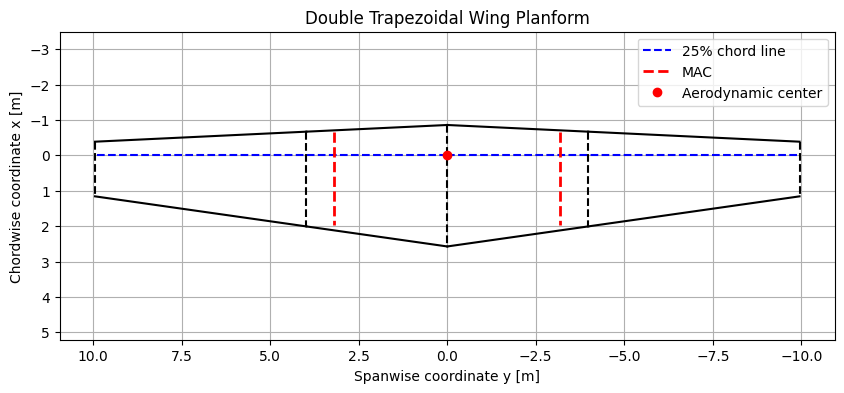

In [379]:
# Wing dimensionning
##2025/12/13 - Wing dimensionning - Léna Aveline

#Constants and design specifications
gamma = 1.4                                                   #Ratio of specific heat for air
P_290 = 30700                                                 #Pressure at flight level 290
M_MO = 0.57                                                   #Maximum operation Mach number
k_n = 1.3                                                     #Factor for maneuvers and gust
k_av = 1.1                                                    #Factor for increase of the local lift coefficient
k_trim = 1.1                                                  #Factor for trimming

################################################################################

#Assumptions/Design choices
AR=8                                                          #Aspect ratio (assumption made for initial propulsion sizing)
TR=0.45                                                       #Taper ratio [0.3;0.5]
phi25 = 0.0                                                   #No sweep at 25% chord

################################################################################

#Calculations
##Wings Geometry
S_wing = (mTO_str*g)/W_S_str_com                              #Wing area [m²]
b_wing = sqrt(AR*S_wing)                                      #Span [m]
c_root = (2*S_wing)/(b_wing*(1+TR))                           #Root chord [m]
c_tip = TR*c_root                                             #Tip chord [m]
c_mid = S_wing/b_wing                                         #Mid chord [m]

##Wing geometry for double trapezoidal
###Point and chord at kink point (Assumption: kink point at the engine level)
y_kink = 0.4*(b_wing/2)
c_kink = c_root - ((c_root - c_tip)/(b_wing/2)*y_kink)
###Taper Ratios
TR_in = c_kink/c_root
TR_out = c_tip/c_kink
###Mean Aerodynamic Chord
c_mac_in = (2/3)*c_root*((1+TR_in+TR_in**2)/(1+TR_in))
c_mac_out = (2/3)*c_kink*((1+TR_out+TR_out**2)/(1+TR_out))
###MAC positions
y_mac_in = (y_kink/6)*((1+2*TR_in)/(1+TR_in))
y_mac_out = ((((b_wing/2)-y_kink)/6)*((1+2*TR_out)/(1+TR_out)))+y_kink
###Surfaces
S_in = 2*y_kink*((c_root+c_kink)/2)
S_out = 2*((b_wing/2)-y_kink)*((c_kink+c_tip)/2)
###global MAC
c_mac = (S_in*c_mac_in+S_out*c_mac_out)/S_wing
y_mac = (S_in*y_mac_in+S_out*y_mac_out)/S_wing

##Lift coefficients
cl_bas= (W_S_bas_com)*(2/(gamma*P_290*M_MO**2))               #Lift coefficient for baseline
cl_BO_bas = k_n*k_av*k_trim*cl_bas                            #Buffet Onset Lift Coefficient for baseline
cl_DD_bas = k_av*k_trim*cl_bas                                #Drag Divergence Lift coefficient for baseline

cl_str= (W_S_str_com)*(2/(gamma*P_290*M_MO**2))               #Lift coefficient for stretched variant
cl_BO_str = k_n*k_av*k_trim*cl_str                            #Buffet Onset Lift Coefficient for stretched variant
cl_DD_str = k_av*k_trim*cl_str                                #Drag Divergence Lift coefficient for stretched variant


################################################################################

#Results
print(" === Wing geometry === ")
print("Wing surface =", round(float(S_wing), 2), "m²")
print("Wing span =", round(float(b_wing),2), "m")
print("Mid chord lenght =", round(float(c_mid), 2), "m")
print("Root chord lenght =", round(float(c_root), 2), "m")
print("Tip chord lenght =", round(float(c_tip), 2), "m")
print()
print(" === Geometry for double trapezoidal === ")
print("kink point is in y =", round(float(y_kink), 2))
print("Chord at kink point =", round(float(c_kink), 2), "m")
print()
print("Mean aerodynamic chord for the inner panel is in y =", round(float(y_mac_in), 2),)
print("Mean aerodynamic chord for the inner panel =",round(float(c_mac_in), 2), "m")
print()
print("Mean aerodynamic chord for the outer panel is in y =", round(float(y_mac_out), 2),)
print("Mean aerodynamic chord for the outer panel =",round(float(c_mac_out), 2), "m")
print()
print("Total surface of inner panels =", round(float(S_in), 2), "m²")
print("Total surface of outer panels =", round(float(S_out), 2), "m²")
print()
print("Mean aerodynamic chord is in y =", round(float(y_mac), 2))
print("Mean aerodynamic chord =",round(float(c_mac), 2), "m")
print()
print(" === Lift coefficients === ")
print("Lift coefficient for baseline = ", round(float(cl_bas), 2))
print("Buffet Onset lift coefficient for baseline =", round(float(cl_BO_bas), 3))
print("Drag Divergence lift coefficient for baseline =", round(float(cl_DD_bas), 3))
print()
print("Lift coefficient for stretched variant = ", round(float(cl_str), 2))
print("Buffet Onset lift coefficient for stretched variant =", round(float(cl_BO_str), 3))
print("Drag Divergence lift coefficient for stretched variant =", round(float(cl_DD_str), 3))
print()

################################################################################

#Sketch of double trapezoid wing
##Sweep at 25% chord
phi25_rad = np.deg2rad(phi25)

def section_coords(y, c):
    x_25 = y * np.tan(phi25_rad)
    x_le = x_25 - 0.25 * c
    x_te = x_25 + 0.75 * c
    return x_le, x_te, x_25

##Sections
###Root
y_r = 0.0
x_le_r, x_te_r, x_25_r = section_coords(y_r, c_root)
###Kink
x_le_k, x_te_k, x_25_k = section_coords(y_kink, c_kink)
###Tip
y_t = b_wing / 2
x_le_t, x_te_t, x_25_t = section_coords(y_t, c_tip)

##Plotting
plt.figure(figsize=(10, 4))
###Leading edge
plt.plot([y_r, y_kink], [x_le_r, x_le_k], 'k')
plt.plot([y_kink, y_t], [x_le_k, x_le_t], 'k')
###Trailing edge
plt.plot([y_r, y_kink], [x_te_r, x_te_k], 'k')
plt.plot([y_kink, y_t], [x_te_k, x_te_t], 'k')
###Other half
plt.plot([-y_r, -y_kink], [x_le_r, x_le_k], 'k')
plt.plot([-y_kink, -y_t], [x_le_k, x_le_t], 'k')
plt.plot([-y_r, -y_kink], [x_te_r, x_te_k], 'k')
plt.plot([-y_kink, -y_t], [x_te_k, x_te_t], 'k')
###Sweep line
plt.plot([0, y_t], [x_25_r, x_25_t], 'b--', label='25% chord line')
plt.plot([0, -y_t], [x_25_r, x_25_t], 'b--')
###Root chord
plt.plot([y_r, y_r], [x_le_r, x_te_r], 'k--')
###Kink chord
plt.plot([y_kink, y_kink], [x_le_k, x_te_k], 'k--')
plt.plot([-y_kink, -y_kink], [x_le_k, x_te_k], 'k--')
###Tip chord
plt.plot([y_t, y_t], [x_le_t, x_te_t], 'k--')
plt.plot([-y_t, -y_t], [x_le_t, x_te_t], 'k--')

##Mean aerodynamic chord
x_25_mac = y_mac * np.tan(phi25_rad)
x_le_mac = x_25_mac - 0.25 * c_mac
x_te_mac = x_25_mac + 0.75 * c_mac
plt.plot([y_mac, y_mac], [x_le_mac, x_te_mac], 'r--', linewidth=2, label='MAC')
plt.plot([-y_mac, -y_mac], [x_le_mac, x_te_mac], 'r--', linewidth=2)

##Aerodynamic center
x_ac = x_25_r
y_ac = 0.0
plt.plot(y_ac, x_ac, 'ro', label='Aerodynamic center')


plt.xlabel("Spanwise coordinate y [m]")
plt.ylabel("Chordwise coordinate x [m]")
plt.title("Double Trapezoidal Wing Planform")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.show()

# Empennage Dimensionning


In [380]:
# Empennage dimensionning
##16/12/2025 - Empennage dimensioning -

from math import *
import matplotlib.pyplot as plt
import numpy as np

#Coefficients according to slide 18 raymer
c_h= 0.8                                    #Horizontal tailplane volume coefficient
c_v=0.07                                    #Vertical tailplane volume coefficient
lf= 20                                      #fuselage lenght in m. Just an assumption now
lh=0.5*lf                                   #distance between aerodynamic center of wing and tailplane in m
lv=lh

################################################################################

#Calculations
Sh=(c_h*S_wing*c_mid)/lh                    #Horizontal tailplane area in m²
Sv=(c_v*S_wing*b_wing)/lv                   #Vertical tailplane area in m²

################################################################################

#Results
print("Horizontal tailplane area =", round(float(Sh),2), "m²")
print("Vertical tailplane area =", round(float(Sv),2), "m²")


Horizontal tailplane area = 9.85 m²
Vertical tailplane area = 6.9 m²


In [381]:
# Fuselage Dimensioning
##22/12/2025 - Fuselage Dimensionning - Michael Riedl

from math import *
import matplotlib.pyplot as plt
import numpy as np

#Constants/given values

SW=20                                       #Seat width including armrests (in)
WA=20                                       #Width of the passenger aisle (in)

roh_cargo=160                               #Average density of cargo (kg/m³)
roh_Bag=165                                 #Average density of Luggage (kg/m³)

GSV=0.028                                   #Galley storage volume needed per passenger (m³)

################################################################################

#Design choices/estimations/assumptions

SPR=4                                       #Seats per Row
SP=36                                       #Seat pitch (in)

lc_bas=14                                   #length of the cabin for the base variante according to slide 12 (m)
lc_str=22                                   #length of the cabin for the stretch variante according to slide 12 (m)

################################################################################

#Calculations
##Cross-section
d=(SPR*SW+WA)*2.54/100                      #inner diameter of the fuselage (m)
tw=0.02*d+0.0254                            #wall thickness of the fuselage (m)
tf=1.5*tw                                   #floor thickness (m)
D=d+2*tw                                    #outer diameter of the fuselage (m)

#X-axis lengths
l_cockpit=1.5*D                             #Length of the cockpit 1.3-1.7 (m)
l_tail=3.0*D                                #Length of the tail 2.7-3.2 (m)
l_ges_bas=l_tail+l_cockpit+lc_bas           #total length of the base aircraft (m)
l_ges_str=l_tail+l_cockpit+lc_str           #total length of the stretched aircraft (m)

##cargo
V_Cargo=mFrght/roh_cargo                    #Volume of the cargo (m³)
V_Bag_bas=(mLugg*NbPass_bas)/roh_Bag        #Volume of the Luggage for the base variante (m³)
V_Bag_str=(mLugg*NbPass_str)/roh_Bag        #Volume of the Luggage for the stretched variante (m³)

##Galleys
V_Gal_bas=GSV*NbPass_bas                    #Total galleys storage volume for the base variante (m³)
V_Gal_str=GSV*NbPass_str                    #Total galleys storage volume for the stretched variante (m³)

################################################################################

#Results
print(" === Cross-section === ")
print("Inner diameter =", round(float(d),2), "m")
print("Outer diameter =", round(float(D),2), "m")
print("Wall thickness =", round(float(tw),2), "m")
print("Floor thickness =", round(float(tf),2), "m")
print()
print(" === X-axis lengths === ")
print("Cockpit length", round(float(l_cockpit),2), "m")
print("Base variant cabin length =", round(float(lc_bas),2), "m")
print("Stretched variant cabin length =", round(float(lc_str),2), "m")
print("Tail length =", round(float(l_tail),2), "m")
print()
print("Base variant total length =", round(float(l_ges_bas),2), "m")
print("Stretched variant total length =", round(float(l_ges_str),2), "m")
print()
print(" === Cargo === ")
print("Cargo volume", round(float(V_Cargo),3), "m³")
print("Base variant lugage volume =", round(float(V_Bag_bas),3), "m³")
print("Stretched variant lugage volume =", round(float(V_Bag_str),3), "m³")
print()
print(" === Galleys === ")
print("Base variant galleys storage volume =", round(float(V_Gal_bas),3), "m³")
print("Stretched variant galleys storage volume =", round(float(V_Gal_str),3), "m³")

 === Cross-section === 
Inner diameter = 2.54 m
Outer diameter = 2.69 m
Wall thickness = 0.08 m
Floor thickness = 0.11 m

 === X-axis lengths === 
Cockpit length 4.04 m
Base variant cabin length = 14.0 m
Stretched variant cabin length = 22.0 m
Tail length = 8.08 m

Base variant total length = 26.12 m
Stretched variant total length = 34.12 m

 === Cargo === 
Cargo volume 3.125 m³
Base variant lugage volume = 3.491 m³
Stretched variant lugage volume = 5.091 m³

 === Galleys === 
Base variant galleys storage volume = 1.344 m³
Stretched variant galleys storage volume = 1.96 m³
